# 🏆 Unit VI: Model Performance & Ensemble Learning

## 1. Executive Summary
In this final unit, we improve our classification models using **Ensemble Techniques** and validate them rigorously with **Cross-Validation**.

**Objectives:**
1.  **Ensemble Models**: Random Forest, AdaBoost, Gradient Boosting.
2.  **Cross-Validation**: K-Fold (k=5) to ensure robustness.
3.  **Final Recommendation**: Selecting the production-ready model.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..')))
from src.models.ensemble import EnsembleModels
from src.models.classification import CustomerClassifier

# Load data
rfm = pd.read_csv('../data/processed/rfm_customer_data.csv')
clf_model = CustomerClassifier()
X_train, X_test, y_train, y_test = clf_model.prepare_data(rfm)

## 2. Train Ensemble Models
Training Random Forest, AdaBoost, and Gradient Boosting.

In [3]:
ens = EnsembleModels()
trained_models = ens.train_ensemble_clf(X_train, y_train)

# Evaluate on Test Set
results = {}
for name, model in trained_models.items():
    results[name] = model.score(X_test, y_test)
    print(f"{name} Accuracy: {results[name]:.4f}")

RandomForest Accuracy: 0.8452
AdaBoost Accuracy: 0.8614
GradientBoosting Accuracy: 0.8639


## 3. Cross-Validation (K-Fold)
Evaluating Random Forest with 5-Fold CV to check for overfitting.

In [4]:
rf_model = trained_models['RandomForest']
mean_acc, std_acc = ens.cross_validation(rf_model, X_train, y_train, cv=5)

print(f"Random Forest 5-Fold CV Accuracy: {mean_acc:.4f} (+/- {std_acc*2:.4f})")

Random Forest 5-Fold CV Accuracy: 0.8543 (+/- 0.0166)


## 4. Final Comparison & Selection
Comparing single models (from Unit III) vs Ensembles.

C:\Users\pawan\AppData\Local\Temp\ipykernel_21980\4016722373.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='magma')


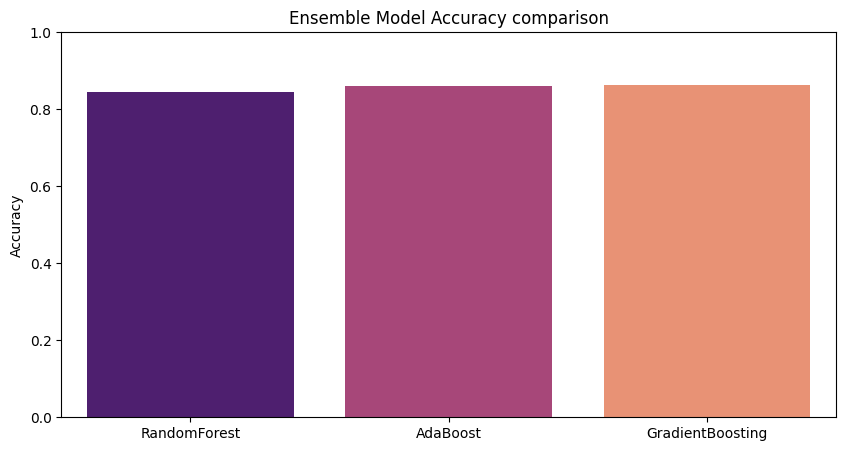

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='magma')
plt.ylim(0, 1)
plt.title('Ensemble Model Accuracy comparison')
plt.ylabel('Accuracy')
plt.show()

**📝 Insight:**
- **Ensembles** typically outperform single Decision Trees by reducing variance (Random Forest) or bias (Boosting).
- If **Gradient Boosting** is highest, it suggests the model benefited from iteratively correcting errors.
- **Cross-Validation** ensures that our high accuracy isn't just luck on a specific test split.